# RCM Denial Prediction & Prevention Engine
### Full ML Pipeline — EDA → Cleaning → Feature Engineering → Training → Evaluation

**Dataset:** `healthcare_insurance_claims_dataset.csv` — 5,000 healthcare claims, 19 features  
**Target:** `ClaimOutcome` — 1 (Paid/Processed = clean pass), 0 (Rejected/Pending/In Review = problem)  
**Models:** XGBoost vs Random Forest — best model saved as `denial_model.pkl`

---
## Section 1 — Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import shap

from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries loaded successfully.')

All libraries loaded successfully.


/home/anush/Documents/GitHub/RCMDenialPrediction/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
root = Path().resolve().parent
dataset_path = root / "data" / "healthcare_insurance_claims_dataset.csv"

df = pd.read_csv(dataset_path)
print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')
df.head(3)

Dataset loaded: 5000 rows x 19 columns


,ClaimID,PatientID,ProviderID,CompanyName,ClaimAmount,ClaimDate,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ProviderLocation,ClaimType,ClaimSubmissionMethod,InsuranceStatus
0,CLM00001,PAT46463,PRV1106,UnitedHealth Group,8417.25,2021-06-21,E11.9,99285,43,Female,Cardiology,In Review,75720,Domestic Partner,Full-Time,MO,Outpatient,Clearinghouse,Approved
1,CLM00002,PAT48427,PRV6925,UnitedHealth Group,32603.86,2023-03-31,I25.10,70553,66,Female,Surgery,Rejected,88397,Married,Self-Employed,MO,Inpatient,Electronic,Approved
2,CLM00003,PAT42087,PRV3677,UnitedHealth Group,38813.17,2020-12-01,I25.10,99214,37,Male,Surgery,In Review,138422,Single,Full-Time,NC,Specialist,Electronic,Approved


---
## Section 2 — Exploratory Data Analysis (EDA)

In [3]:
print('=== DATA TYPES ===')
print(df.dtypes)
print('\n=== MISSING VALUES ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else 'No missing values found.')
print('\n=== CARDINALITY ===')
card = pd.DataFrame({'Unique': df.nunique(), 'Pct': (df.nunique()/len(df)*100).round(1)})
card['Note'] = card['Pct'].apply(lambda x: 'DROP — ID column' if x > 90 else ('Good categorical' if x < 5 else ''))
print(card)

=== DATA TYPES ===
ClaimID                        str
PatientID                      str
ProviderID                     str
CompanyName                    str
ClaimAmount                float64
ClaimDate                      str
DiagnosisCode                  str
ProcedureCode                int64
PatientAge                   int64
PatientGender                  str
ProviderSpecialty              str
ClaimStatus                    str
PatientIncome                int64
PatientMaritalStatus           str
PatientEmploymentStatus        str
ProviderLocation               str
ClaimType                      str
ClaimSubmissionMethod          str
InsuranceStatus                str
dtype: object

=== MISSING VALUES ===
No missing values found.

=== CARDINALITY ===
                         Unique    Pct              Note
ClaimID                    5000  100.0  DROP — ID column
PatientID                  4877   97.5  DROP — ID column
ProviderID                 3806   76.1                  
Comp

In [4]:
print('ClaimStatus value counts:')
print(df['ClaimStatus'].value_counts())
print('\nInsuranceStatus value counts:')
print(df['InsuranceStatus'].value_counts())

ClaimStatus value counts:
ClaimStatus
Rejected     1040
In Review    1011
Pending       998
Processed     977
Paid          974
Name: count, dtype: int64

InsuranceStatus value counts:
InsuranceStatus
Approved        3871
Partial          542
Pending          268
Denied           209
Under Review     110
Name: count, dtype: int64


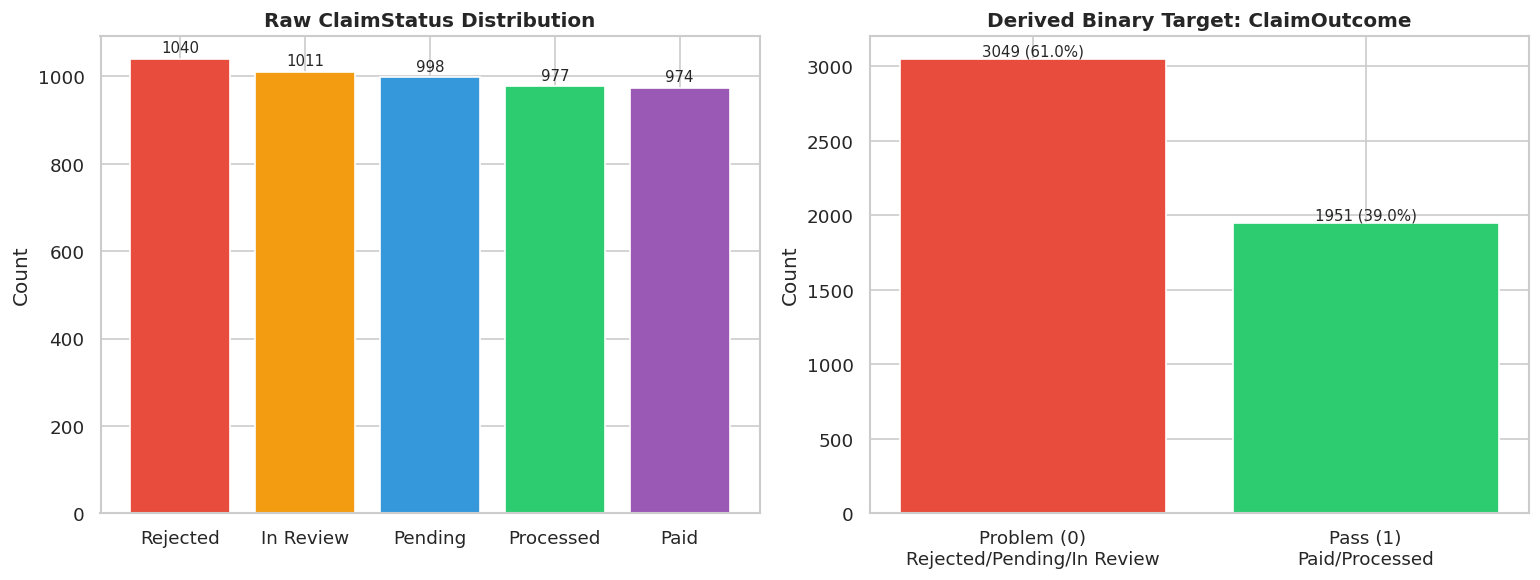

Class balance — Problem: 3049 (61.0%) | Pass: 1951 (39.0%)


In [5]:
# Build derived target: 1=Paid/Processed (clean pass), 0=everything else (problem)
df['ClaimOutcome'] = df['ClaimStatus'].apply(
    lambda x: 1 if x in ['Paid', 'Processed'] else 0
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw ClaimStatus
cs = df['ClaimStatus'].value_counts()
colors_raw = ['#e74c3c','#f39c12','#3498db','#2ecc71','#9b59b6']
axes[0].bar(cs.index, cs.values, color=colors_raw, edgecolor='white')
axes[0].set_title('Raw ClaimStatus Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i,(v) in enumerate(cs.values):
    axes[0].text(i, v+15, str(v), ha='center', fontsize=9)

# Derived binary target
oc = df['ClaimOutcome'].value_counts()
axes[1].bar(['Problem (0)\nRejected/Pending/In Review', 'Pass (1)\nPaid/Processed'],
            [oc[0], oc[1]], color=['#e74c3c','#2ecc71'], edgecolor='white')
axes[1].set_title('Derived Binary Target: ClaimOutcome', fontweight='bold')
axes[1].set_ylabel('Count')
for i,v in enumerate([oc[0], oc[1]]):
    pct = round(v/len(df)*100,1)
    axes[1].text(i, v+20, f'{v} ({pct}%)', ha='center', fontsize=9)

plt.tight_layout()
plot_path_01 = root / "plots" / "plot_01_target_distribution.png"
plt.savefig(plot_path_01, bbox_inches='tight')
plt.show()
print(f'Class balance — Problem: {oc[0]} ({oc[0]/len(df)*100:.1f}%) | Pass: {oc[1]} ({oc[1]/len(df)*100:.1f}%)')

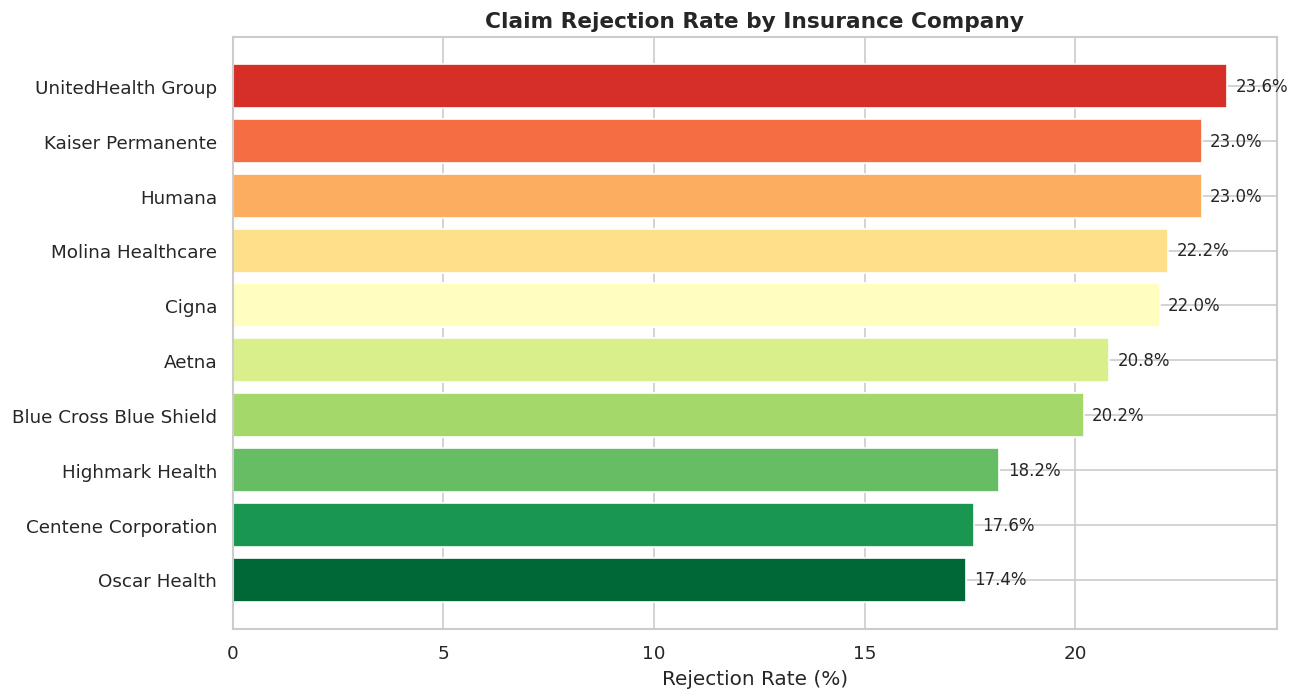

In [6]:
# Rejection rate by insurance company
df['isRejected'] = (df['ClaimStatus'] == 'Rejected').astype(int)

company_stats = df.groupby('CompanyName').agg(
    TotalClaims=('ClaimStatus','count'),
    RejectionRate=('isRejected', lambda x: round(x.mean()*100, 1))
).sort_values('RejectionRate', ascending=True).reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.RdYlGn_r([i/len(company_stats) for i in range(len(company_stats))])
bars = ax.barh(company_stats['CompanyName'], company_stats['RejectionRate'], color=colors, edgecolor='white')
for bar, val in zip(bars, company_stats['RejectionRate']):
    ax.text(val+0.2, bar.get_y()+bar.get_height()/2, f'{val}%', va='center', fontsize=10)
ax.set_xlabel('Rejection Rate (%)')
ax.set_title('Claim Rejection Rate by Insurance Company', fontsize=13, fontweight='bold')
plt.tight_layout()
plot_path_02 = root / "plots" / "plot_02_rejection_by_company.png"
plt.savefig(plot_path_02, bbox_inches='tight')
plt.show()

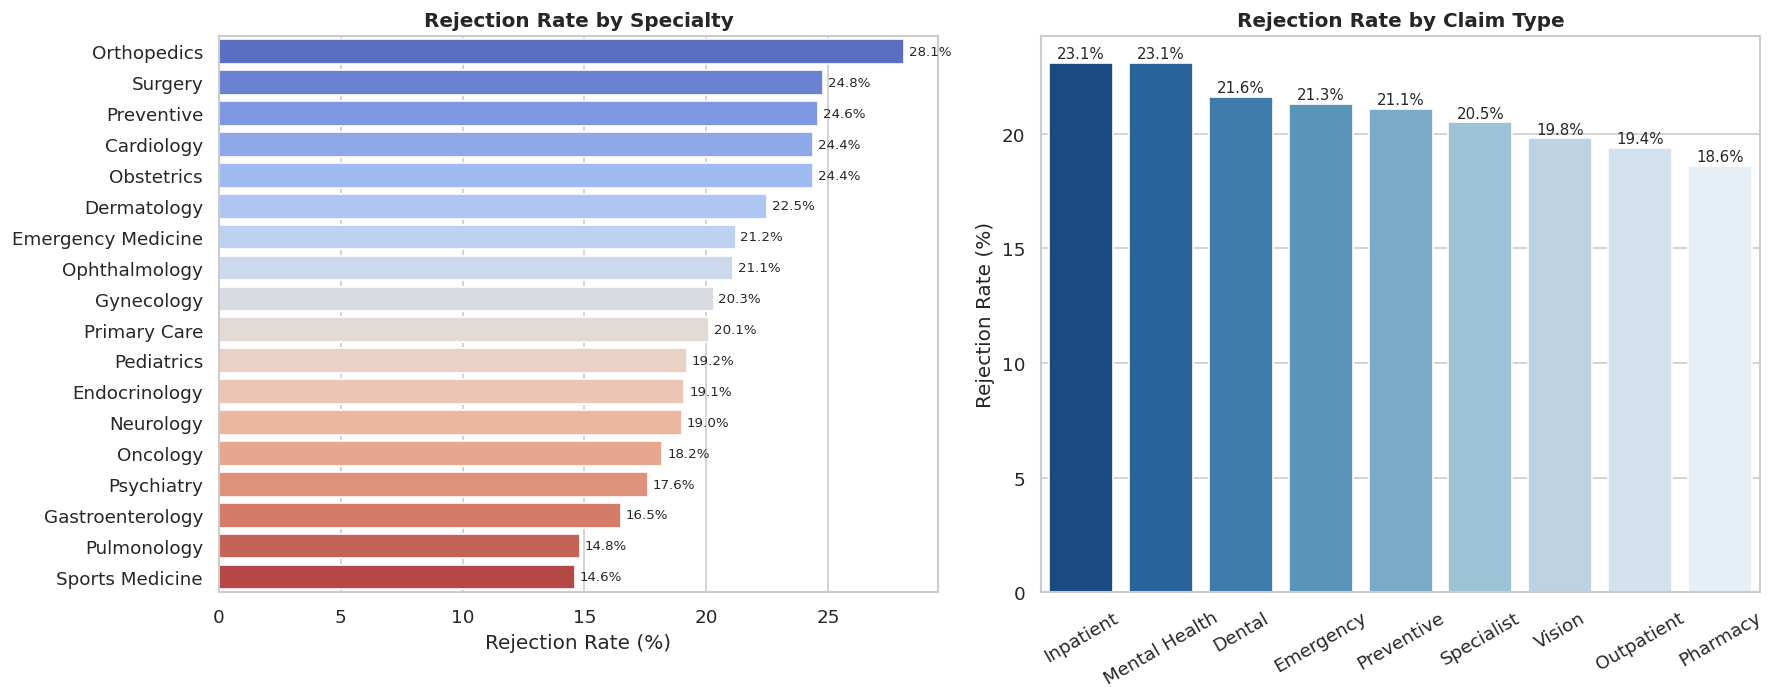

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# By Specialty
spec = df.groupby('ProviderSpecialty')['isRejected'].mean().mul(100).round(1).sort_values(ascending=False).reset_index()
spec.columns = ['ProviderSpecialty','RejectionRate']
sns.barplot(data=spec, x='RejectionRate', y='ProviderSpecialty', palette='coolwarm', ax=axes[0])
axes[0].set_title('Rejection Rate by Specialty', fontweight='bold')
axes[0].set_xlabel('Rejection Rate (%)')
axes[0].set_ylabel('')
for p in axes[0].patches:
    axes[0].text(p.get_width()+0.2, p.get_y()+p.get_height()/2, f'{p.get_width():.1f}%', va='center', fontsize=8)

# By ClaimType
ct = df.groupby('ClaimType')['isRejected'].mean().mul(100).round(1).sort_values(ascending=False).reset_index()
ct.columns = ['ClaimType','RejectionRate']
sns.barplot(data=ct, x='ClaimType', y='RejectionRate', palette='Blues_r', ax=axes[1])
axes[1].set_title('Rejection Rate by Claim Type', fontweight='bold')
axes[1].set_ylabel('Rejection Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].text(p.get_x()+p.get_width()/2, p.get_height()+0.2, f'{p.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plot_path_03 = root / "plots" / "plot_03_specialty_claimtype.png"
plt.savefig(plot_path_03, bbox_inches='tight')
plt.show()

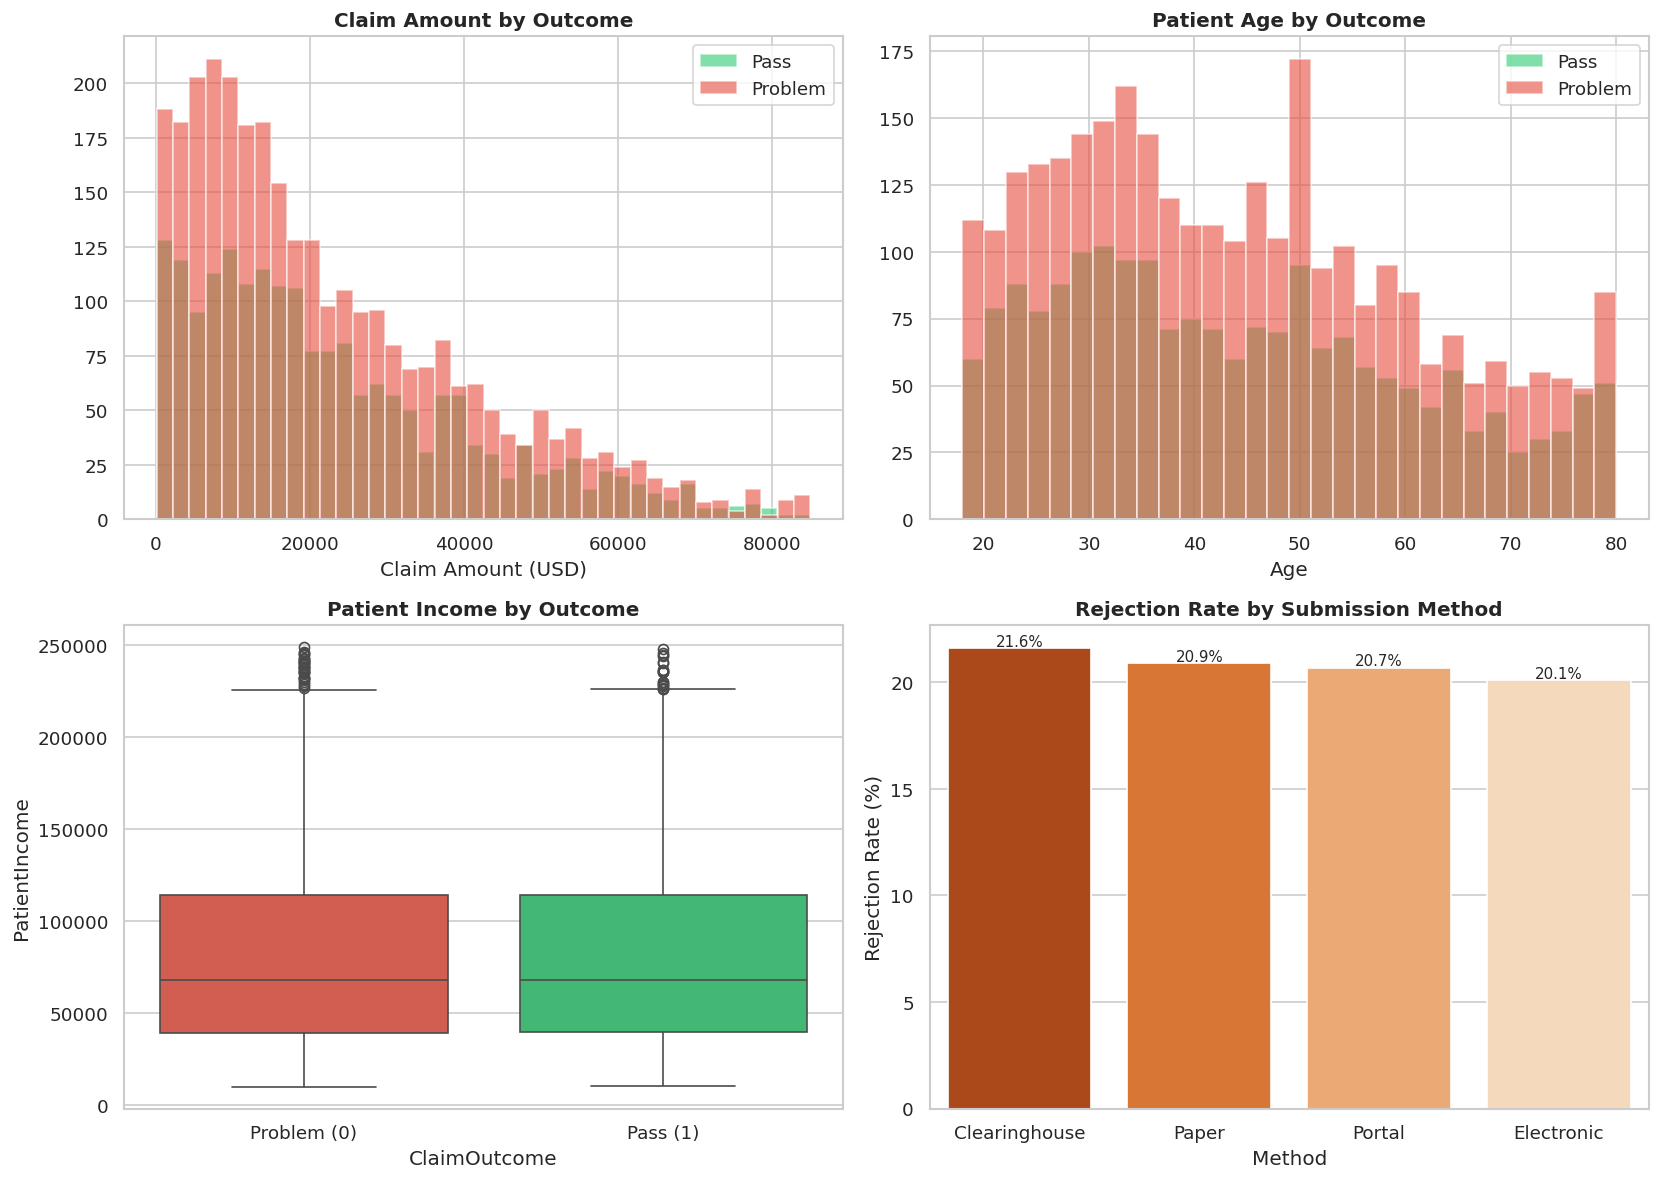

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Claim Amount distribution by outcome
for outcome, label, color in [(1,'Pass','#2ecc71'),(0,'Problem','#e74c3c')]:
    axes[0,0].hist(df[df['ClaimOutcome']==outcome]['ClaimAmount'], bins=40,
                   alpha=0.6, label=label, color=color, edgecolor='white')
axes[0,0].set_title('Claim Amount by Outcome', fontweight='bold')
axes[0,0].set_xlabel('Claim Amount (USD)')
axes[0,0].legend()

# Patient Age by outcome
for outcome, label, color in [(1,'Pass','#2ecc71'),(0,'Problem','#e74c3c')]:
    axes[0,1].hist(df[df['ClaimOutcome']==outcome]['PatientAge'], bins=30,
                   alpha=0.6, label=label, color=color, edgecolor='white')
axes[0,1].set_title('Patient Age by Outcome', fontweight='bold')
axes[0,1].set_xlabel('Age')
axes[0,1].legend()

# Patient Income by outcome boxplot
sns.boxplot(data=df, x='ClaimOutcome', y='PatientIncome',
            palette={'0':'#e74c3c', '1':'#2ecc71'}, ax=axes[1,0])
axes[1,0].set_title('Patient Income by Outcome', fontweight='bold')
axes[1,0].set_xticklabels(['Problem (0)', 'Pass (1)'])

# Submission method vs rejection
sm = df.groupby('ClaimSubmissionMethod')['isRejected'].mean().mul(100).round(1).sort_values(ascending=False).reset_index()
sm.columns = ['Method','RejectionRate']
sns.barplot(data=sm, x='Method', y='RejectionRate', palette='Oranges_r', ax=axes[1,1])
axes[1,1].set_title('Rejection Rate by Submission Method', fontweight='bold')
axes[1,1].set_ylabel('Rejection Rate (%)')
for p in axes[1,1].patches:
    axes[1,1].text(p.get_x()+p.get_width()/2, p.get_height()+0.1, f'{p.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plot_path_04 = root / "plots" / "plot_04_numeric_features.png"
plt.savefig(plot_path_04, bbox_inches='tight')
plt.show()

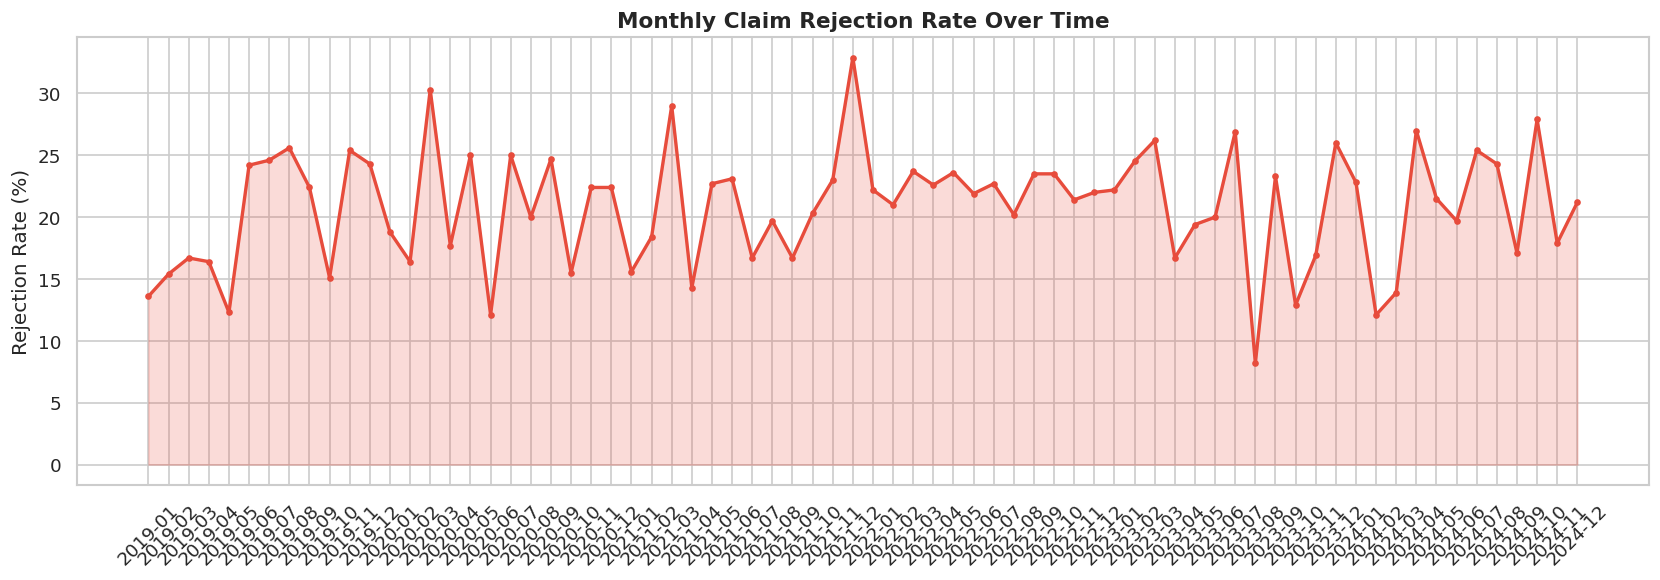

In [9]:
df['ClaimDate'] = pd.to_datetime(df['ClaimDate'])
df['YearMonth'] = df['ClaimDate'].dt.to_period('M')

monthly_rejection = df.groupby('YearMonth')['isRejected'].agg(['sum','count'])
monthly_rejection['RejectionRate'] = (monthly_rejection['sum'] / monthly_rejection['count'] * 100).round(1)
monthly_rejection.index = monthly_rejection.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_rejection.index, monthly_rejection['RejectionRate'],
        color='#e74c3c', linewidth=2, marker='o', markersize=3)
ax.fill_between(monthly_rejection.index, monthly_rejection['RejectionRate'],
                alpha=0.2, color='#e74c3c')
ax.set_title('Monthly Claim Rejection Rate Over Time', fontsize=13, fontweight='bold')
ax.set_ylabel('Rejection Rate (%)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plot_path_05 = root / "plots" / "plot_05_rejection_over_time.png"
plt.savefig(plot_path_05, bbox_inches='tight')
plt.show()

---
## Section 3 — Data Cleaning

In [10]:
# Drop high-cardinality ID columns — no predictive value
# ClaimID, PatientID, ProviderID are unique identifiers
# ClaimDate is replaced by engineered date features below
# isRejected and YearMonth are temporary EDA columns

df_clean = df.drop(columns=[
    'ClaimID', 'PatientID', 'ProviderID',
    'isRejected', 'YearMonth'
])

print('Columns after dropping IDs and raw target:')
print(df_clean.columns.tolist())
print(f'Shape: {df_clean.shape}')

Columns after dropping IDs and raw target:
['CompanyName', 'ClaimAmount', 'ClaimDate', 'DiagnosisCode', 'ProcedureCode', 'PatientAge', 'PatientGender', 'ProviderSpecialty', 'ClaimStatus', 'PatientIncome', 'PatientMaritalStatus', 'PatientEmploymentStatus', 'ProviderLocation', 'ClaimType', 'ClaimSubmissionMethod', 'InsuranceStatus', 'ClaimOutcome']
Shape: (5000, 17)


In [11]:
# Fix data types
df_clean['ClaimDate'] = pd.to_datetime(df_clean['ClaimDate'])
df_clean['ProcedureCode'] = df_clean['ProcedureCode'].astype(str)  # treat as category not number

# Confirm no nulls
print('Null values after cleaning:', df_clean.isnull().sum().sum())

Null values after cleaning: 0


In [12]:
# Outlier check on ClaimAmount and PatientIncome using IQR
for col in ['ClaimAmount', 'PatientIncome']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]
    print(f'{col}: {outliers} extreme outliers (using 3x IQR fence)')
    # Cap rather than drop — preserves data
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print('\nClaim Amount after capping:')
print(df_clean['ClaimAmount'].describe().round(2))

ClaimAmount: 0 extreme outliers (using 3x IQR fence)
PatientIncome: 0 extreme outliers (using 3x IQR fence)

Claim Amount after capping:
count     5000.00
mean     22928.51
std      18256.01
min        101.82
25%       8631.75
50%      17756.81
75%      33457.40
max      84941.92
Name: ClaimAmount, dtype: float64


In [13]:
import json

rate_lookup = {
    'SpecialtyProblemRate':  df_clean.groupby('ProviderSpecialty')['ClaimOutcome'].apply(lambda x: 1 - x.mean()).to_dict(),
    'CompanyProblemRate':    df_clean.groupby('CompanyName')['ClaimOutcome'].apply(lambda x: 1 - x.mean()).to_dict(),
    'LocationProblemRate':   df_clean.groupby('ProviderLocation')['ClaimOutcome'].apply(lambda x: 1 - x.mean()).to_dict(),
    'ClaimTypeProblemRate':  df_clean.groupby('ClaimType')['ClaimOutcome'].apply(lambda x: 1 - x.mean()).to_dict(),
    'DiagnosisProblemRate':  df_clean.groupby('DiagnosisCode')['ClaimOutcome'].apply(lambda x: 1 - x.mean()).to_dict(),
    'ProcedureProblemRate':  df_clean.groupby('ProcedureCode')['ClaimOutcome'].apply(lambda x: 1 - x.mean()).to_dict(),
}

with open(root / "models" / "rate_lookup.json", 'w') as f:
    json.dump(rate_lookup, f)

print('Rate lookup tables saved.')

Rate lookup tables saved.


Saving cleaned dataset

In [14]:
cleaned_path = root / "data" / "dataset_cleaned.csv"

df_clean.to_csv(cleaned_path)

---
## Section 4 — Feature Engineering

In [15]:
# --- Date features ---
# Extract temporal patterns from ClaimDate
df_clean['ClaimYear']    = df_clean['ClaimDate'].dt.year
df_clean['ClaimMonth']   = df_clean['ClaimDate'].dt.month
df_clean['ClaimDayOfWeek'] = df_clean['ClaimDate'].dt.dayofweek   # 0=Mon, 6=Sun
df_clean['ClaimQuarter'] = df_clean['ClaimDate'].dt.quarter
df_clean['IsWeekend']    = (df_clean['ClaimDate'].dt.dayofweek >= 5).astype(int)
df_clean['IsEndOfMonth'] = (df_clean['ClaimDate'].dt.day >= 25).astype(int)

# Days since earliest claim — captures recency
min_date = df_clean['ClaimDate'].min()
df_clean['DaysSinceEarliestClaim'] = (df_clean['ClaimDate'] - min_date).dt.days

# Drop raw date now that we've extracted features
df_clean.drop(columns=['ClaimDate'], inplace=True)

print('Date features created: ClaimYear, ClaimMonth, ClaimDayOfWeek, ClaimQuarter, IsWeekend, IsEndOfMonth, DaysSinceEarliestClaim')

Date features created: ClaimYear, ClaimMonth, ClaimDayOfWeek, ClaimQuarter, IsWeekend, IsEndOfMonth, DaysSinceEarliestClaim


In [16]:
# --- Claim Amount features ---
# High dollar claims face more scrutiny from payers
df_clean['IsHighDollarClaim'] = (df_clean['ClaimAmount'] > 30000).astype(int)
df_clean['ClaimAmountLog']    = np.log1p(df_clean['ClaimAmount'])  # normalize skewed distribution

# Amount relative to specialty average — is this claim unusually expensive for its specialty?
specialty_avg = df_clean.groupby('ProviderSpecialty')['ClaimAmount'].transform('mean')
df_clean['ClaimAmountVsSpecialtyAvg'] = (df_clean['ClaimAmount'] / specialty_avg).round(3)

print('Amount features created: IsHighDollarClaim, ClaimAmountLog, ClaimAmountVsSpecialtyAvg')

Amount features created: IsHighDollarClaim, ClaimAmountLog, ClaimAmountVsSpecialtyAvg


In [17]:
# --- Age & Income bucket features ---
# Bucketing reduces noise from individual values
df_clean['AgeBucket'] = pd.cut(
    df_clean['PatientAge'],
    bins=[0, 25, 40, 55, 65, 100],
    labels=['18-25', '26-40', '41-55', '56-65', '65+']
).astype(str)

df_clean['IncomeBucket'] = pd.cut(
    df_clean['PatientIncome'],
    bins=[0, 30000, 60000, 100000, 200000, 999999],
    labels=['Low', 'Lower-Mid', 'Mid', 'Upper-Mid', 'High']
).astype(str)

print('Patient features created: AgeBucket, IncomeBucket')

Patient features created: AgeBucket, IncomeBucket


In [18]:
# --- Prior Authorization Risk ---
# Certain CPT codes typically require prior auth from payers
# Based on real CMS/AMA guidelines for common auth-required procedures
HIGH_AUTH_PROCEDURES = {
    '70553',  # MRI Brain with contrast
    '27447',  # Total knee replacement
    '66984',  # Cataract surgery
    '43239',  # Upper GI endoscopy
    '92004',  # Ophthalmology exam
    '93000',  # Electrocardiogram
}

df_clean['PriorAuthRequired'] = df_clean['ProcedureCode'].apply(
    lambda x: 1 if x in HIGH_AUTH_PROCEDURES else 0
)

print('Prior auth required for', df_clean['PriorAuthRequired'].sum(), 'claims')
print('Auth-required procedure rejection rate:',
      round(df_clean[df_clean['PriorAuthRequired']==1]['ClaimOutcome'].apply(lambda x: 1-x).mean()*100, 1), '%')

Prior auth required for 914 claims
Auth-required procedure rejection rate: 61.7 %


In [19]:
# --- Diagnosis & Procedure category features ---
# ICD-10 codes: first character = broad disease category
# CPT codes: first 2 digits = procedure category
df_clean['DiagnosisCategory'] = df_clean['DiagnosisCode'].str[0]
df_clean['ProcedureCategory'] = df_clean['ProcedureCode'].str[:2]

# ICD-CPT mismatch flag — simplified but meaningful signal
# Maps diagnosis category to expected procedure prefixes
VALID_DX_PROC = {
    'E': ['99', '80'],   # Endocrine → office visit, lab
    'I': ['93', '99', '71'],  # Circulatory → cardiology, office, imaging
    'J': ['99', '71', '85'],  # Respiratory → office, imaging, lab
    'K': ['43', '99'],   # Digestive → endoscopy, office
    'M': ['27', '97', '20'],  # Musculoskeletal → ortho, PT, joint
    'F': ['90', '99'],   # Mental health → therapy, office
    'C': ['99', '85'],   # Neoplasms → office, lab
    'N': ['99', '80'],   # Genitourinary → office, lab
    'Z': ['99', '92'],   # Preventive → office, vision
    'G': ['99', '93', '90'],  # Nervous system → office, cardio, therapy
    'R': ['99', '71', '85'],  # Symptoms → office, imaging, lab
}

def flag_mismatch(row):
    valid = VALID_DX_PROC.get(row['DiagnosisCategory'], [])
    return 0 if row['ProcedureCategory'] in valid else 1

df_clean['ICDCPTMismatch'] = df_clean.apply(flag_mismatch, axis=1)
print('ICD-CPT mismatch flags:', df_clean['ICDCPTMismatch'].sum(), 'claims flagged')

ICD-CPT mismatch flags: 2067 claims flagged


In [20]:
# --- Historical denial rate features ---
# Compute rejection rate per group and attach back to each claim
# This teaches the model 'historically, claims like this get rejected X% of the time'

# Only compute on groups with >= 20 claims to avoid noisy small-sample rates
MIN_SAMPLES = 20

def safe_denial_rate(df, group_col, target_col='ClaimOutcome', min_n=MIN_SAMPLES):
    """Compute (1 - outcome) rate = problem rate per group, attach to df."""
    df['_problem'] = 1 - df[target_col]
    rates = df.groupby(group_col)['_problem'].agg(['mean', 'count'])
    rates = rates[rates['count'] >= min_n]['mean']
    df.drop(columns=['_problem'], inplace=True)
    return df[group_col].map(rates)

df_clean['SpecialtyProblemRate']  = safe_denial_rate(df_clean, 'ProviderSpecialty')
df_clean['CompanyProblemRate']    = safe_denial_rate(df_clean, 'CompanyName')
df_clean['LocationProblemRate']   = safe_denial_rate(df_clean, 'ProviderLocation')
df_clean['ClaimTypeProblemRate']  = safe_denial_rate(df_clean, 'ClaimType')
df_clean['DiagnosisProblemRate']  = safe_denial_rate(df_clean, 'DiagnosisCode')
df_clean['ProcedureProblemRate']  = safe_denial_rate(df_clean, 'ProcedureCode')

# Fill any NaN from small groups with overall problem rate
overall_problem_rate = 1 - df_clean['ClaimOutcome'].mean()
rate_cols = ['SpecialtyProblemRate','CompanyProblemRate','LocationProblemRate',
             'ClaimTypeProblemRate','DiagnosisProblemRate','ProcedureProblemRate']
df_clean[rate_cols] = df_clean[rate_cols].fillna(overall_problem_rate)

print('Historical problem rate features created for:', rate_cols)

Historical problem rate features created for: ['SpecialtyProblemRate', 'CompanyProblemRate', 'LocationProblemRate', 'ClaimTypeProblemRate', 'DiagnosisProblemRate', 'ProcedureProblemRate']


In [21]:
# --- Composite risk flag ---
# A claim is 'high risk' if it triggers multiple risk factors simultaneously
df_clean['CompositeRiskScore'] = (
    df_clean['PriorAuthRequired'] +
    df_clean['IsHighDollarClaim'] +
    df_clean['ICDCPTMismatch'] +
    (df_clean['ClaimSubmissionMethod'] == 'Paper').astype(int) +
    (df_clean['CompanyProblemRate'] > overall_problem_rate).astype(int)
)

print('Composite risk score distribution:')
print(df_clean['CompositeRiskScore'].value_counts().sort_index())

Composite risk score distribution:
CompositeRiskScore
0     232
1    1747
2    1683
3     881
4     388
5      69
Name: count, dtype: int64


In [22]:
print('Feature engineering complete.')
print(f'Total features before encoding: {df_clean.shape[1]}')
print('\nAll columns:')
print(df_clean.columns.tolist())

Feature engineering complete.
Total features before encoding: 39

All columns:
['CompanyName', 'ClaimAmount', 'DiagnosisCode', 'ProcedureCode', 'PatientAge', 'PatientGender', 'ProviderSpecialty', 'ClaimStatus', 'PatientIncome', 'PatientMaritalStatus', 'PatientEmploymentStatus', 'ProviderLocation', 'ClaimType', 'ClaimSubmissionMethod', 'InsuranceStatus', 'ClaimOutcome', 'ClaimYear', 'ClaimMonth', 'ClaimDayOfWeek', 'ClaimQuarter', 'IsWeekend', 'IsEndOfMonth', 'DaysSinceEarliestClaim', 'IsHighDollarClaim', 'ClaimAmountLog', 'ClaimAmountVsSpecialtyAvg', 'AgeBucket', 'IncomeBucket', 'PriorAuthRequired', 'DiagnosisCategory', 'ProcedureCategory', 'ICDCPTMismatch', 'SpecialtyProblemRate', 'CompanyProblemRate', 'LocationProblemRate', 'ClaimTypeProblemRate', 'DiagnosisProblemRate', 'ProcedureProblemRate', 'CompositeRiskScore']


Saving feature engineered dataset

In [23]:
featured_path = root / "data" / "dataset_featured.csv"

df_clean.to_csv(featured_path)

---
## Section 5 — Model Preparation (Encoding & Split)

In [24]:
# Identify categorical columns to encode
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
# Remove target if accidentally included
cat_cols = [c for c in cat_cols if c != 'ClaimOutcome']
print('Categorical columns to encode:', cat_cols)

# Label encode all categoricals
# XGBoost and RF handle label-encoded categoricals well for tabular data
encoders = {}
df_model = df_clean.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

print('\nEncoding complete. All dtypes now numeric.')
print(df_model.dtypes.value_counts())

Categorical columns to encode: ['CompanyName', 'DiagnosisCode', 'ProcedureCode', 'PatientGender', 'ProviderSpecialty', 'ClaimStatus', 'PatientMaritalStatus', 'PatientEmploymentStatus', 'ProviderLocation', 'ClaimType', 'ClaimSubmissionMethod', 'InsuranceStatus', 'AgeBucket', 'IncomeBucket', 'DiagnosisCategory', 'ProcedureCategory']

Encoding complete. All dtypes now numeric.
int64      26
float64     9
int32       4
Name: count, dtype: int64


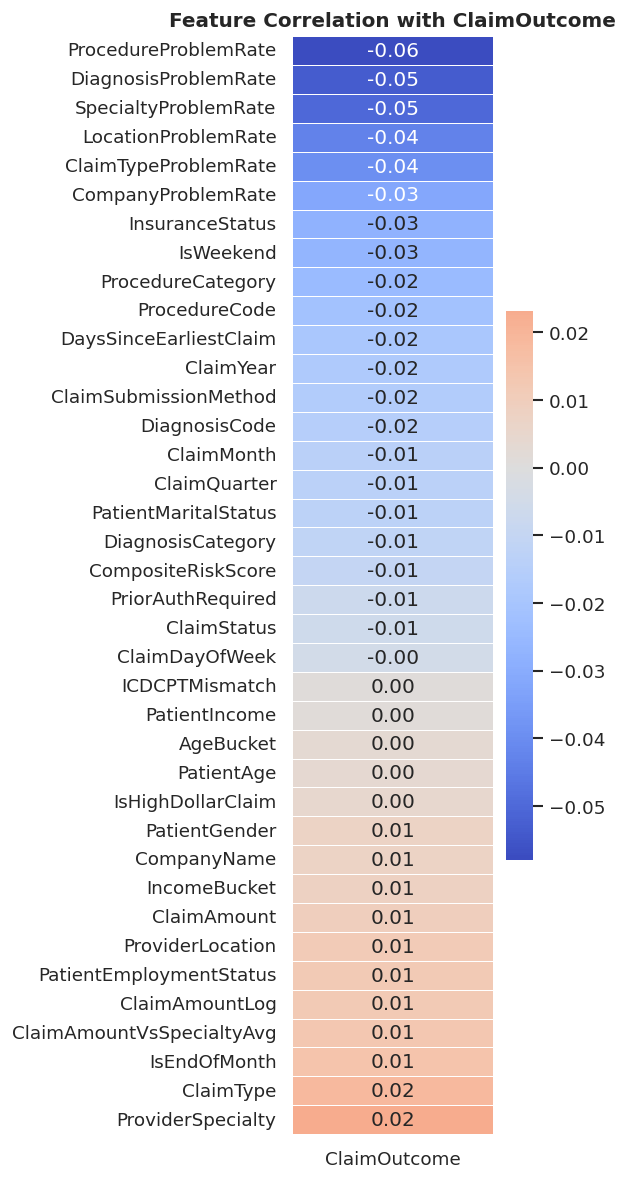

In [25]:
# Correlation heatmap — numeric features vs target
numeric_features = df_model.select_dtypes(include=[np.number]).columns.tolist()
corr = df_model[numeric_features].corr()[['ClaimOutcome']].drop('ClaimOutcome').sort_values('ClaimOutcome')

fig, ax = plt.subplots(figsize=(5, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.5})
ax.set_title('Feature Correlation with ClaimOutcome', fontweight='bold')
plt.tight_layout()
plot_path_06 = root / "plots" / "plot_06_correlation.png"
plt.savefig(plot_path_06, bbox_inches='tight')
plt.show()

In [26]:
X = df_model.drop(columns=['ClaimOutcome', 'ClaimStatus'])
y = df_model['ClaimOutcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set:  {X_train.shape[0]} rows')
print(f'Test set:      {X_test.shape[0]} rows')
print(f'Features:      {X_train.shape[1]}')
print(f'\nClass balance in train — Pass: {y_train.sum()} | Problem: {(y_train==0).sum()}')
print(f'Class balance in test  — Pass: {y_test.sum()} | Problem: {(y_test==0).sum()}')

Training set:  4000 rows
Test set:      1000 rows
Features:      37

Class balance in train — Pass: 1561 | Problem: 2439
Class balance in test  — Pass: 390 | Problem: 610


In [27]:
# Compute class weights to handle imbalance
# This tells the model to penalize missing the minority class more
classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}
scale_pos_weight = weights[0] / weights[1]  # for XGBoost

print(f'Class weights — Problem(0): {weights[0]:.3f} | Pass(1): {weights[1]:.3f}')
print(f'XGBoost scale_pos_weight: {scale_pos_weight:.3f}')

Class weights — Problem(0): 0.820 | Pass(1): 1.281
XGBoost scale_pos_weight: 0.640


---
## Section 6 — Model Training (XGBoost vs Random Forest)

In [28]:
print('Training XGBoost...')

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print('XGBoost training complete.')

Training XGBoost...
XGBoost training complete.


In [29]:
print('Training Random Forest...')

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print('Random Forest training complete.')

Training Random Forest...
Random Forest training complete.


---
## Section 7 — Model Evaluation & Comparison

In [30]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Accuracy': round((y_pred == y_test).mean() * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall': round(recall_score(y_test, y_pred) * 100, 2),
        'F1 Score': round(f1_score(y_test, y_pred) * 100, 2),
        'AUC-ROC': round(roc_auc_score(y_test, y_proba) * 100, 2),
        '_y_pred': y_pred,
        '_y_proba': y_proba
    }

xgb_results = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')
rf_results  = evaluate_model(rf_model,  X_test, y_test, 'Random Forest')

metrics_df = pd.DataFrame([xgb_results, rf_results]).drop(columns=['_y_pred','_y_proba'])
metrics_df = metrics_df.set_index('Model')

print('=== MODEL COMPARISON ===')
display(metrics_df)

=== MODEL COMPARISON ===


,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Model,,,,,
XGBoost,58.9,37.35,7.95,13.11,51.12
Random Forest,57.3,42.19,25.64,31.90,52.11


In [31]:
# Cross-validation for more robust comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_cv = cross_val_score(xgb_model, X, y, cv=cv, scoring='f1', n_jobs=-1)
rf_cv  = cross_val_score(rf_model,  X, y, cv=cv, scoring='f1', n_jobs=-1)

print('5-Fold Cross Validation F1 Scores:')
print(f'  XGBoost:       {xgb_cv.mean():.3f} (+/- {xgb_cv.std():.3f})')
print(f'  Random Forest: {rf_cv.mean():.3f} (+/- {rf_cv.std():.3f})')

5-Fold Cross Validation F1 Scores:
  XGBoost:       0.165 (+/- 0.024)
  Random Forest: 0.317 (+/- 0.030)


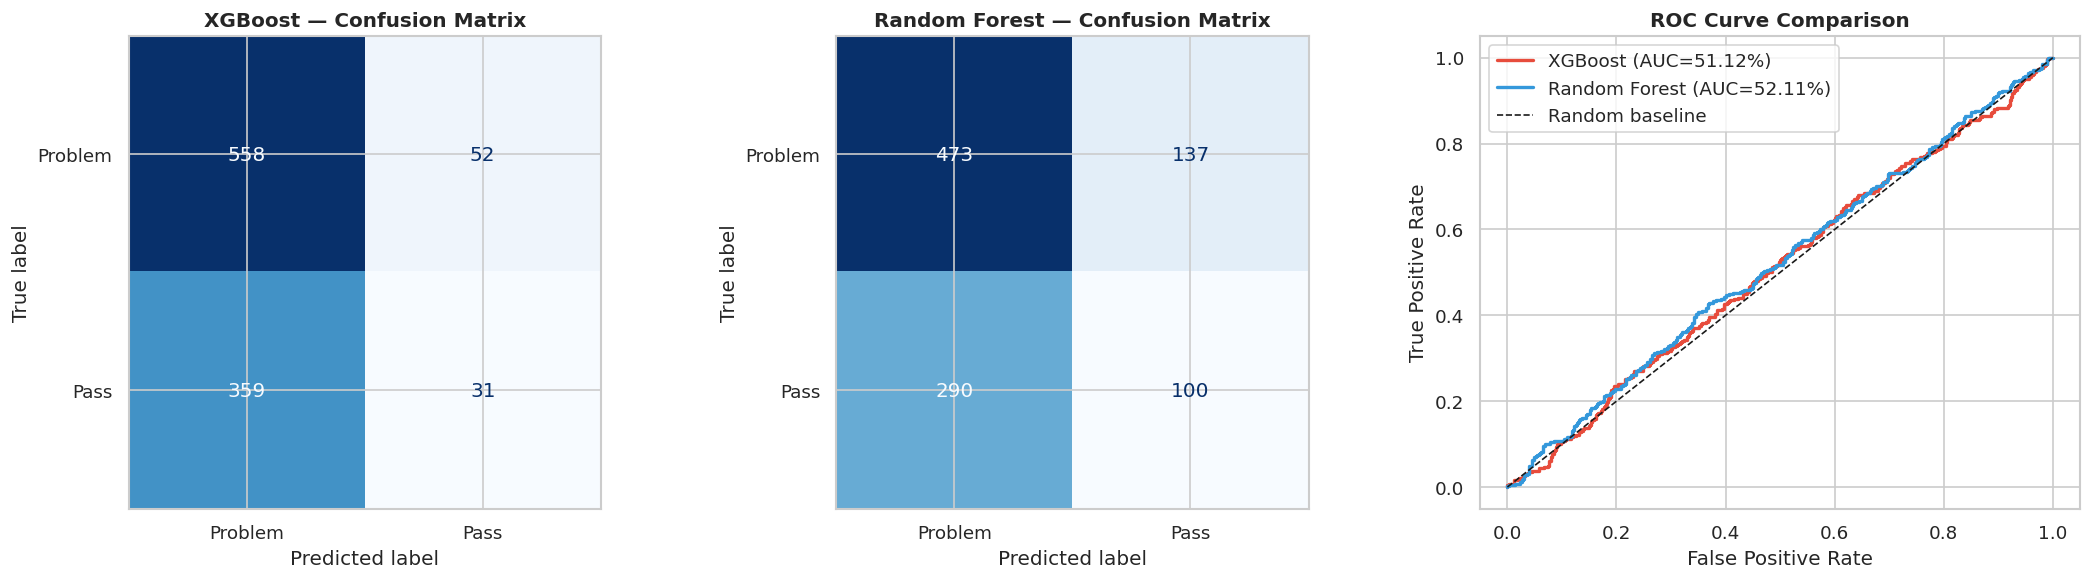

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Confusion Matrices ---
for ax, result, model_name in [
    (axes[0], xgb_results, 'XGBoost'),
    (axes[1], rf_results,  'Random Forest')
]:
    cm = confusion_matrix(y_test, result['_y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Problem', 'Pass'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name} — Confusion Matrix', fontweight='bold')

# --- ROC Curves (both on same plot) ---
for result, name, color in [
    (xgb_results, 'XGBoost', '#e74c3c'),
    (rf_results, 'Random Forest', '#3498db')
]:
    fpr, tpr, _ = roc_curve(y_test, result['_y_proba'])
    axes[2].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{name} (AUC={result['AUC-ROC']}%)")

axes[2].plot([0,1],[0,1],'k--', linewidth=1, label='Random baseline')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve Comparison', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plot_path_07 = root / "plots" / "plot_07_model_evaluation.png"
plt.savefig(plot_path_07, bbox_inches='tight')
plt.show()

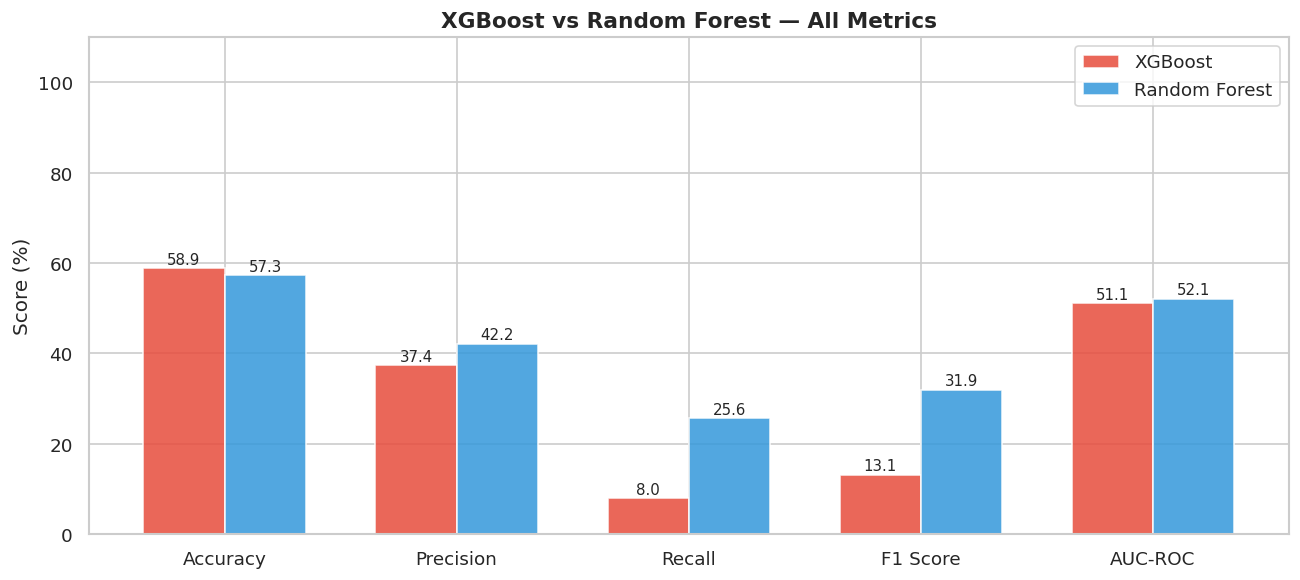

In [33]:
# Metric comparison bar chart
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
xgb_vals = [xgb_results[m] for m in metric_names]
rf_vals  = [rf_results[m]  for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, xgb_vals, width, label='XGBoost', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + width/2, rf_vals,  width, label='Random Forest', color='#3498db', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 110)
ax.set_title('XGBoost vs Random Forest — All Metrics', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plot_path_08 = root / "plots" / "plot_08_metrics_comparison.png"
plt.savefig(plot_path_08, bbox_inches='tight')
plt.show()

In [34]:
print('=== XGBoost Classification Report ===')
print(classification_report(y_test, xgb_results['_y_pred'], target_names=['Problem (0)', 'Pass (1)']))

print('=== Random Forest Classification Report ===')
print(classification_report(y_test, rf_results['_y_pred'], target_names=['Problem (0)', 'Pass (1)']))

=== XGBoost Classification Report ===
              precision    recall  f1-score   support

 Problem (0)       0.61      0.91      0.73       610
    Pass (1)       0.37      0.08      0.13       390

    accuracy                           0.59      1000
   macro avg       0.49      0.50      0.43      1000
weighted avg       0.52      0.59      0.50      1000

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

 Problem (0)       0.62      0.78      0.69       610
    Pass (1)       0.42      0.26      0.32       390

    accuracy                           0.57      1000
   macro avg       0.52      0.52      0.50      1000
weighted avg       0.54      0.57      0.54      1000



---
## Section 8 — SHAP Feature Importance & Explainability

In [35]:
# SHAP for XGBoost — explains WHY the model made each prediction
print('Computing SHAP values for XGBoost (this may take a moment)...')

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_test)

print('SHAP values computed.')

Computing SHAP values for XGBoost (this may take a moment)...
SHAP values computed.


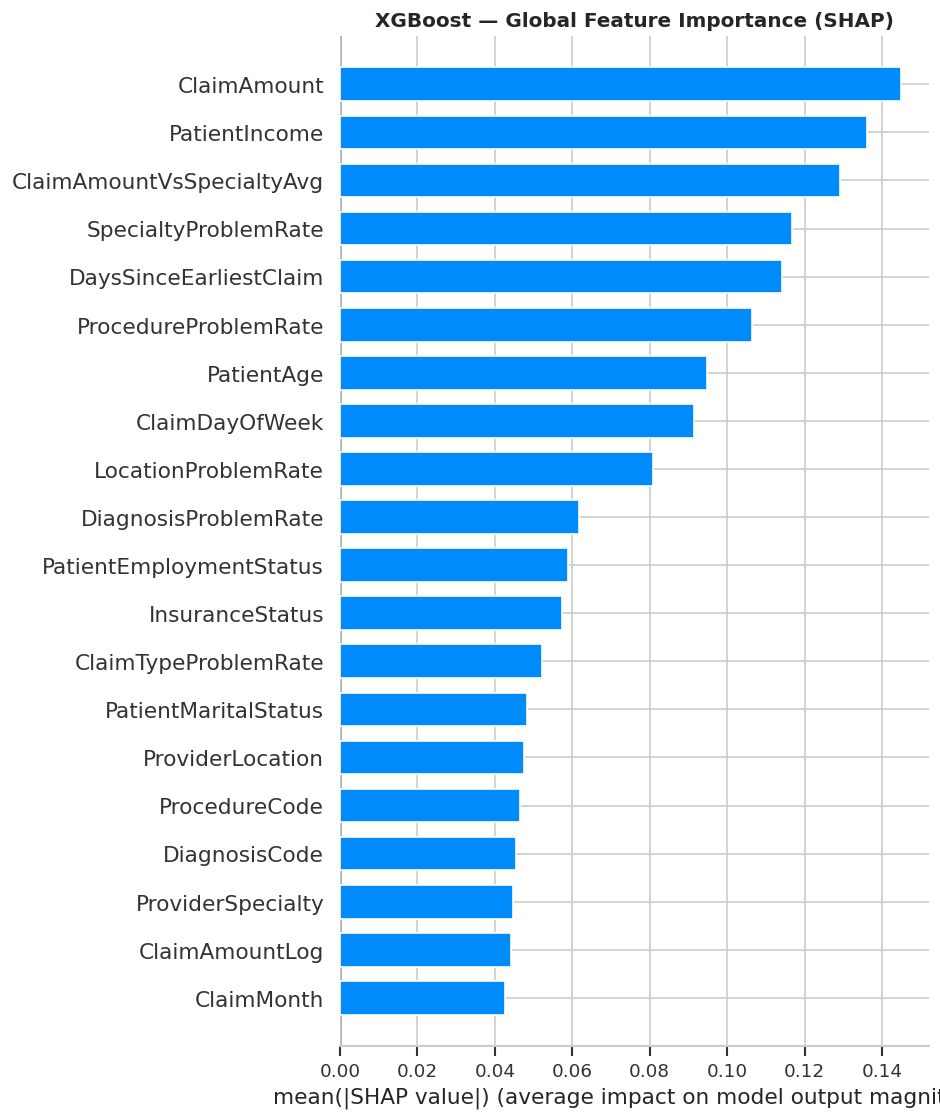

In [36]:
# Global feature importance — which features matter most overall
plt.figure(figsize=(10, 8))
shap.summary_plot(xgb_shap_values, X_test, plot_type='bar',
                  feature_names=X_test.columns.tolist(), show=False)
plt.title('XGBoost — Global Feature Importance (SHAP)', fontweight='bold')
plt.tight_layout()
plot_path_09 = root / "plots" / "plot_09_shap_importance.png"
plt.savefig(plot_path_09, bbox_inches='tight')
plt.show()

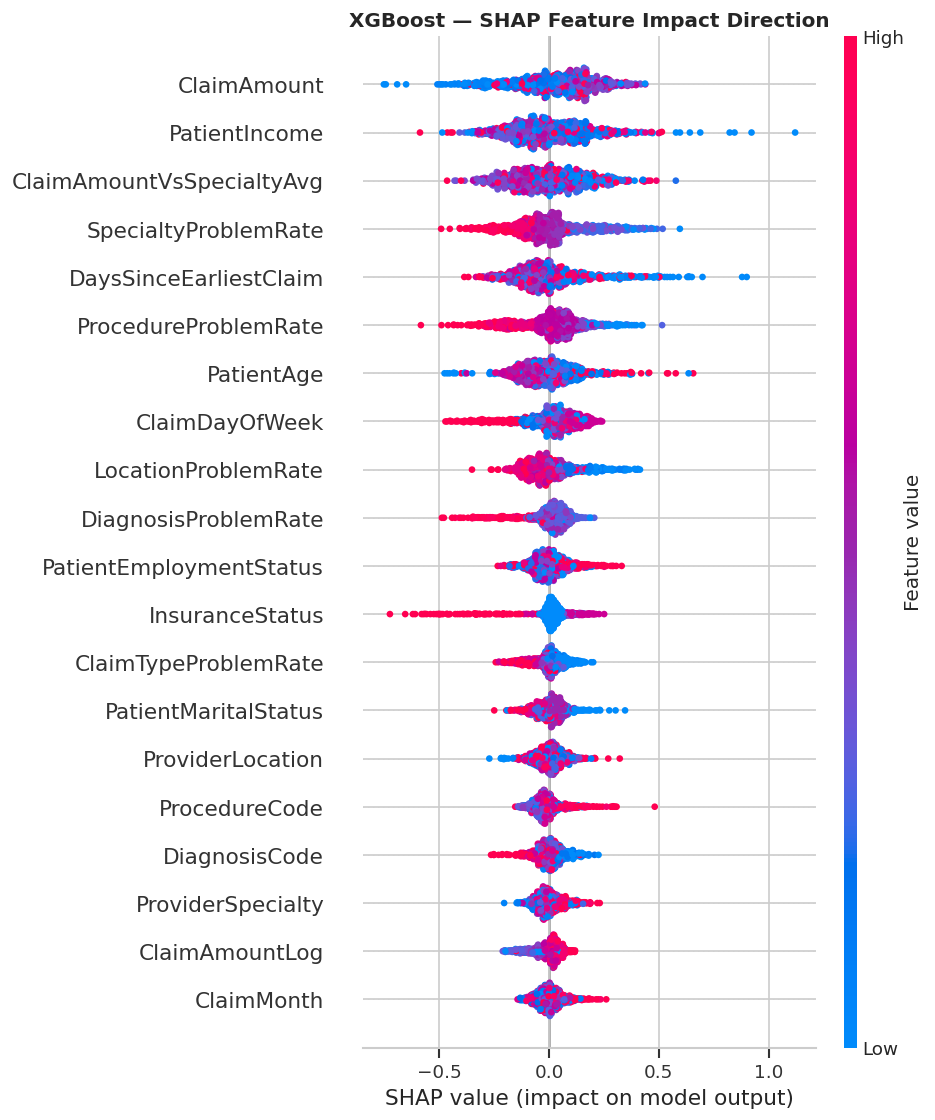

In [37]:
# SHAP beeswarm — shows direction of impact (high value = push toward pass or problem)
plt.figure(figsize=(10, 8))
shap.summary_plot(xgb_shap_values, X_test,
                  feature_names=X_test.columns.tolist(), show=False)
plt.title('XGBoost — SHAP Feature Impact Direction', fontweight='bold')
plt.tight_layout()
plot_path_10 = root / "plots" / "plot_10_shap_beeswarm.png"
plt.savefig(plot_path_10, bbox_inches='tight')
plt.show()

Computing SHAP values for Random Forest...


<Figure size 1200x960 with 0 Axes>

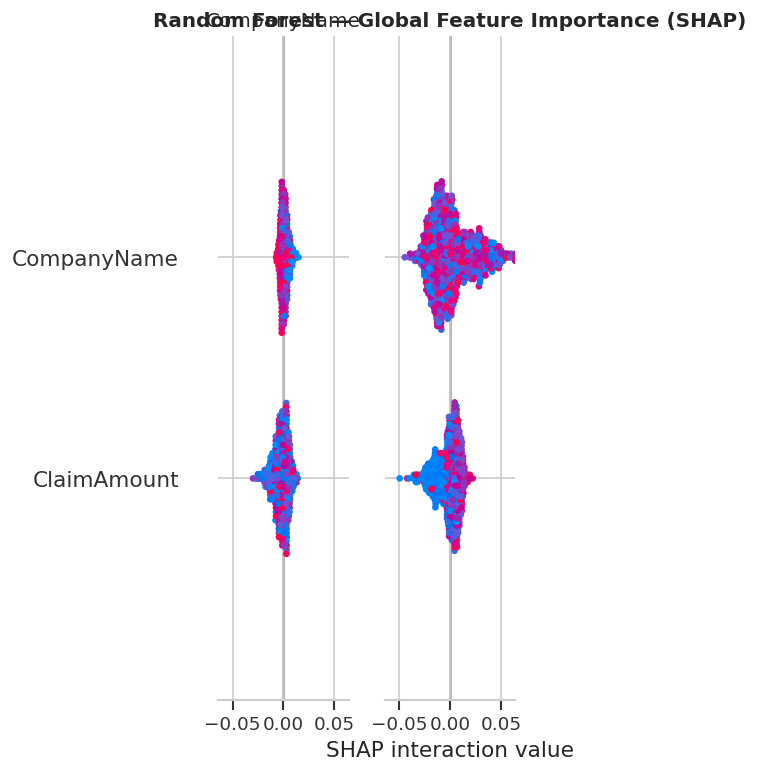

In [38]:
# SHAP for Random Forest
print('Computing SHAP values for Random Forest...')
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_test)

# RF returns shap values per class — take class 1 (Pass)
rf_shap_class1 = rf_shap_values[1] if isinstance(rf_shap_values, list) else rf_shap_values

plt.figure(figsize=(10, 8))
shap.summary_plot(rf_shap_class1, X_test, plot_type='bar',
                  feature_names=X_test.columns.tolist(), show=False)
plt.title('Random Forest — Global Feature Importance (SHAP)', fontweight='bold')
plt.tight_layout()
plot_path_11 = root / "plots" / "plot_11_shap_rf.png"
plt.savefig(plot_path_11, bbox_inches='tight')
plt.show()

Explaining prediction for test claim index 0
Predicted problem probability: 71.0%
Actual label: Problem (0)
Model was: CORRECT


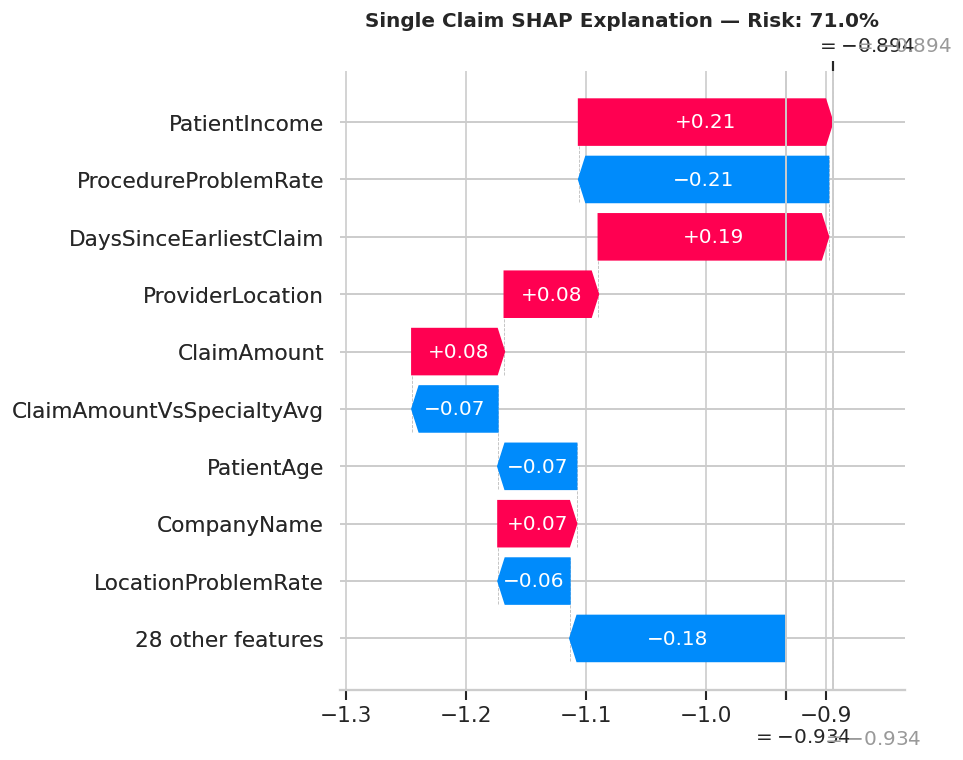

In [39]:
# Single claim explanation — this is what powers the prevention engine
# Show SHAP waterfall for one high-risk claim
high_risk_idx = np.where(xgb_model.predict_proba(X_test)[:,0] > 0.7)[0]

if len(high_risk_idx) > 0:
    idx = high_risk_idx[0]
    risk_score = xgb_model.predict_proba(X_test)[idx][0] * 100
    actual = y_test.iloc[idx]
    predicted_proba = xgb_model.predict_proba(X_test)[idx][0] * 100
    print(f'Explaining prediction for test claim index {idx}')
    print(f'Predicted problem probability: {risk_score:.1f}%')
    print(f'Actual label: {"Problem (0)" if actual == 0 else "Pass (1)"}')
    print(f'Model was: {"CORRECT" if actual == 0 else "WRONG"}')
    shap.plots._waterfall.waterfall_legacy(
        xgb_explainer.expected_value,
        xgb_shap_values[idx],
        feature_names=X_test.columns.tolist(),
        show=False
    )
    plt.title(f'Single Claim SHAP Explanation — Risk: {risk_score:.1f}%', fontweight='bold')
    plt.tight_layout()
    plot_path_12 = root / "plots" / "plot_12_shap_single_claim.png"
    plt.savefig(plot_path_12, bbox_inches='tight')
    plt.show()
else:
    print('No claims above 70% risk threshold in test set.')

---
## Section 9 — Select Best Model & Save

In [40]:
# Select best model based on F1 Score (most balanced metric for imbalanced classes)
best_model_name = 'XGBoost' if xgb_results['F1 Score'] >= rf_results['F1 Score'] else 'Random Forest'
best_model = xgb_model if best_model_name == 'XGBoost' else rf_model

print(f'Best model: {best_model_name}')
print(f'  F1 Score:  {xgb_results["F1 Score"] if best_model_name == "XGBoost" else rf_results["F1 Score"]}%')
print(f'  AUC-ROC:   {xgb_results["AUC-ROC"] if best_model_name == "XGBoost" else rf_results["AUC-ROC"]}%')

# Save model and encoders
model_path = root / "models" / "denial_model.pkl"
encoders_path = root / "models" / "label_encoders.pkl"
names_path = root / "models" / "feature_names.pkl"

joblib.dump(best_model, model_path)
joblib.dump(encoders, encoders_path)
joblib.dump(X_train.columns.tolist(), names_path)

print('\nSaved:')
print('  denial_model.pkl     — trained model')
print('  label_encoders.pkl   — encoders for categorical columns')
print('  feature_names.pkl    — ordered feature list for inference')

Best model: Random Forest
  F1 Score:  31.9%
  AUC-ROC:   52.11%

Saved:
  denial_model.pkl     — trained model
  label_encoders.pkl   — encoders for categorical columns
  feature_names.pkl    — ordered feature list for inference


---
## Section 10 — Prevention Engine (SHAP → Corrective Actions)

In [41]:
# Prevention rules: map engineered features → human readable actions
# These are the corrective actions your FastAPI backend will serve to the React dashboard

PREVENTION_RULES = {
    'PriorAuthRequired': {
        'message': 'This procedure requires prior authorization from the payer.',
        'action': 'Obtain prior authorization before submitting. Contact payer auth line.',
        'severity': 'High'
    },
    'IsHighDollarClaim': {
        'message': 'Claim amount exceeds payer threshold for automatic review.',
        'action': 'Attach medical necessity letter, operative notes, and physician justification.',
        'severity': 'High'
    },
    'ICDCPTMismatch': {
        'message': 'Diagnosis code may not support medical necessity of procedure billed.',
        'action': 'Review with coder — ensure ICD-10 diagnosis aligns with CPT procedure.',
        'severity': 'High'
    },
    'ClaimSubmissionMethod': {
        'message': 'Paper/non-electronic submissions have higher processing error rates.',
        'action': 'Switch to electronic submission via clearinghouse or portal.',
        'severity': 'Medium'
    },
    'CompanyProblemRate': {
        'message': 'This payer has a historically high rejection rate for similar claims.',
        'action': 'Review payer-specific documentation requirements before submitting.',
        'severity': 'Medium'
    },
    'SpecialtyProblemRate': {
        'message': 'This specialty has an elevated historical rejection rate.',
        'action': 'Double-check all specialty-specific billing requirements and modifiers.',
        'severity': 'Medium'
    },
    'DiagnosisProblemRate': {
        'message': 'Claims with this diagnosis code are frequently rejected.',
        'action': 'Attach supporting clinical documentation for this diagnosis.',
        'severity': 'Medium'
    },
    'ProcedureProblemRate': {
        'message': 'This procedure code has a high historical rejection rate.',
        'action': 'Verify procedure is covered under patient plan and attach medical necessity.',
        'severity': 'Medium'
    },
    'ClaimAmountVsSpecialtyAvg': {
        'message': 'Claim amount is significantly above specialty average.',
        'action': 'Ensure all charges are itemized and supported by documentation.',
        'severity': 'Low'
    },
    'InsuranceStatus': {
        'message': 'Insurance status is not fully approved.',
        'action': 'Verify patient insurance eligibility and coverage before submitting.',
        'severity': 'High'
    }
}

print('Prevention rules defined for', len(PREVENTION_RULES), 'features.')

Prevention rules defined for 10 features.


In [42]:
def get_prevention_suggestions(shap_vals, feature_names, threshold=0.05):
    """Given SHAP values for one claim, return ranked corrective actions."""
    suggestions = []
    for feat, shap_val in zip(feature_names, shap_vals):
        # Negative SHAP = pushes toward problem (0) = denial risk
        if shap_val < -threshold and feat in PREVENTION_RULES:
            rule = PREVENTION_RULES[feat]
            suggestions.append({
                'feature': feat,
                'risk_contribution': f'+{abs(round(shap_val*100, 1))}% problem risk',
                'severity': rule['severity'],
                'message': rule['message'],
                'action': rule['action']
            })
    suggestions.sort(key=lambda x: float(x['risk_contribution'].replace('+','').replace('% problem risk','')), reverse=True)
    return suggestions


def predict_with_prevention(model, explainer, shap_values_all, X_test, idx):
    """Full prediction + prevention for one claim."""
    risk_proba = model.predict_proba(X_test.iloc[[idx]])[0][0]  # probability of problem
    risk_score = round(risk_proba * 100, 1)
    risk_level = 'Critical' if risk_score > 75 else 'High' if risk_score > 55 else 'Medium' if risk_score > 35 else 'Low'
    suggestions = get_prevention_suggestions(shap_values_all[idx], X_test.columns.tolist())
    return {
        'risk_score': risk_score,
        'risk_level': risk_level,
        'prevention_suggestions': suggestions
    }


# Demo: run prevention engine on a high-risk claim
if len(high_risk_idx) > 0:
    demo_idx = high_risk_idx[0]
    result = predict_with_prevention(best_model, xgb_explainer, xgb_shap_values, X_test, demo_idx)

    print('=' * 60)
    print(f'  DENIAL RISK SCORE:  {result["risk_score"]}%  [{result["risk_level"]}]')
    print('=' * 60)
    print('\nPREVENTION SUGGESTIONS:')
    for i, s in enumerate(result['prevention_suggestions'], 1):
        print(f'\n  [{s["severity"]}] {s["feature"]} — {s["risk_contribution"]}')
        print(f'  Issue:  {s["message"]}')
        print(f'  Action: {s["action"]}')
    print('\n(These suggestions will be served via FastAPI to your React dashboard.)')

  DENIAL RISK SCORE:  56.2%  [High]

PREVENTION SUGGESTIONS:

  [Medium] ProcedureProblemRate — +20.799999237060547% problem risk
  Issue:  This procedure code has a high historical rejection rate.
  Action: Verify procedure is covered under patient plan and attach medical necessity.

  [Low] ClaimAmountVsSpecialtyAvg — +7.199999809265137% problem risk
  Issue:  Claim amount is significantly above specialty average.
  Action: Ensure all charges are itemized and supported by documentation.

(These suggestions will be served via FastAPI to your React dashboard.)


---
## Section 11 — Final Summary

In [43]:
print('=' * 60)
print('       RCM DENIAL PREDICTION ENGINE — PIPELINE SUMMARY')
print('=' * 60)
print(f'  Dataset:          5,000 claims, 19 original features')
print(f'  Features built:   {X_train.shape[1]} features after engineering')
print(f'  Target:           ClaimOutcome (1=Pass, 0=Problem)')
print(f'  Train/Test split: 80/20 stratified')
print()
print('  --- XGBoost ---')
print(f'  Accuracy:   {xgb_results["Accuracy"]}%')
print(f'  F1 Score:   {xgb_results["F1 Score"]}%')
print(f'  AUC-ROC:    {xgb_results["AUC-ROC"]}%')
print()
print('  --- Random Forest ---')
print(f'  Accuracy:   {rf_results["Accuracy"]}%')
print(f'  F1 Score:   {rf_results["F1 Score"]}%')
print(f'  AUC-ROC:    {rf_results["AUC-ROC"]}%')
print()
print(f'  Best model: {best_model_name} → saved as denial_model.pkl')
print()
print('  Saved files:')
print('    denial_model.pkl     — production model')
print('    label_encoders.pkl   — categorical encoders')
print('    feature_names.pkl    — feature order for inference')
print()
print('=' * 60)

       RCM DENIAL PREDICTION ENGINE — PIPELINE SUMMARY
  Dataset:          5,000 claims, 19 original features
  Features built:   37 features after engineering
  Target:           ClaimOutcome (1=Pass, 0=Problem)
  Train/Test split: 80/20 stratified

  --- XGBoost ---
  Accuracy:   58.9%
  F1 Score:   13.11%
  AUC-ROC:    51.12%

  --- Random Forest ---
  Accuracy:   57.3%
  F1 Score:   31.9%
  AUC-ROC:    52.11%

  Best model: Random Forest → saved as denial_model.pkl

  Saved files:
    denial_model.pkl     — production model
    label_encoders.pkl   — categorical encoders
    feature_names.pkl    — feature order for inference

